In [99]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

from tensorflow.keras.optimizers.legacy import Optimizer
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2

from tensorflow.keras.optimizers import AdamW
import pickle

from time import perf_counter

In [101]:
counts = pd.read_csv('/work/counts_pred.csv')
X = pd.read_csv('/work/preprocessed.csv')
X['No Of Withdrawals'] = StandardScaler().fit_transform(counts)

In [102]:

y = pd.read_csv('/work/target.csv')['Total amount Withdrawn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_calib, y_train, y_calib = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

y_train_norm = (y_train - y_train.min()) / (y_train.max() - y_train.min())
y_test_norm = (y_test - y_test.min()) / (y_test.max() - y_test.min())
y_calib_norm = (y_calib - y_calib.min()) / (y_calib.max() - y_calib.min())


In [111]:
def quantile_loss(q):
    """Custom loss function for quantile regression."""
    def loss(y_true, y_pred):
        error = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q * error, (q - 1) * error))
    return loss


In [112]:
def run_ann(X_train, y_train, q, weight_decay, validation_split=0.1):

    model = keras.Sequential([
        layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        layers.Dense(128, activation="relu"),
        Dropout(0.3),
        layers.Dense(32, activation="relu"),
        Dropout(0.3),
        BatchNormalization(),
        layers.Dense(1, activation="softplus"),
    ])

    optimizer = AdamW(learning_rate=1e-3, weight_decay=weight_decay)

    model.compile(optimizer=optimizer, loss=quantile_loss(q=q), metrics=['mae'])
    history = model.fit(X_train, y_train, epochs=200, validation_split=validation_split, batch_size = 32)
    

    return model, history


In [114]:
cqr_amt_975, history_975 = run_ann(X_train, y_train_norm, q=0.975, weight_decay=1e-2, validation_split=0.1)


Epoch 1/200
229/229 [==============================] - 3s 4ms/step - loss: 0.0279 - mae: 0.6662 - val_loss: 0.0121 - val_mae: 0.4856
Epoch 2/200
229/229 [==============================] - 1s 4ms/step - loss: 0.0143 - mae: 0.4607 - val_loss: 0.0083 - val_mae: 0.3272
Epoch 3/200
229/229 [==============================] - 1s 3ms/step - loss: 0.0098 - mae: 0.3336 - val_loss: 0.0067 - val_mae: 0.2603
Epoch 4/200
229/229 [==============================] - 1s 3ms/step - loss: 0.0080 - mae: 0.2713 - val_loss: 0.0059 - val_mae: 0.2295
Epoch 5/200
229/229 [==============================] - 1s 3ms/step - loss: 0.0069 - mae: 0.2329 - val_loss: 0.0052 - val_mae: 0.1981
Epoch 6/200
229/229 [==============================] - 1s 3ms/step - loss: 0.0066 - mae: 0.2199 - val_loss: 0.0051 - val_mae: 0.1923
Epoch 7/200
229/229 [==============================] - 1s 3ms/step - loss: 0.0060 - mae: 0.2039 - val_loss: 0.0052 - val_mae: 0.1941
Epoch 8/200
229/229 [==============================] - 1s 3ms/step - 

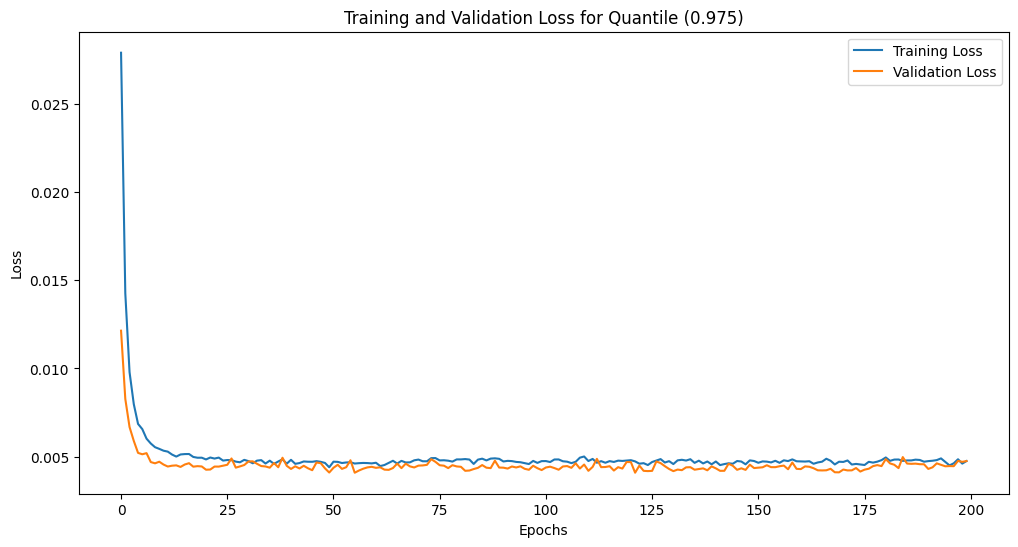

In [115]:

plt.figure(figsize=(12,6))
plt.plot(history_975.history['loss'], label='Training Loss')
plt.plot(history_975.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss for Quantile (0.975)')
plt.show()

In [116]:
t1 = perf_counter()
cqr_amt_975, history_975 = run_ann(X_train, y_train_norm, q=0.975, weight_decay=1e-2, validation_split=0.0)
t2 = perf_counter()

print(f"Elapsed time: {t2 - t1:.2f} seconds")


Epoch 1/200
254/254 [==============================] - 2s 2ms/step - loss: 0.0226 - mae: 0.5622
Epoch 2/200
254/254 [==============================] - 1s 2ms/step - loss: 0.0113 - mae: 0.3906
Epoch 3/200
254/254 [==============================] - 1s 2ms/step - loss: 0.0083 - mae: 0.2826
Epoch 4/200
254/254 [==============================] - 1s 2ms/step - loss: 0.0071 - mae: 0.2374
Epoch 5/200
254/254 [==============================] - 1s 2ms/step - loss: 0.0064 - mae: 0.2133
Epoch 6/200
254/254 [==============================] - 0s 2ms/step - loss: 0.0058 - mae: 0.1995
Epoch 7/200
254/254 [==============================] - 0s 2ms/step - loss: 0.0056 - mae: 0.1871
Epoch 8/200
254/254 [==============================] - 0s 2ms/step - loss: 0.0053 - mae: 0.1818
Epoch 9/200
254/254 [==============================] - 0s 1ms/step - loss: 0.0053 - mae: 0.1793
Epoch 10/200
254/254 [==============================] - 0s 1ms/step - loss: 0.0051 - mae: 0.1720
Epoch 11/200
254/254 [=================

In [117]:

y_pred_amt_ub = cqr_amt_975.predict(X_test).flatten()
y_pred_amt_ub = (y_pred_amt_ub * (y_test.max() - y_test.min()) + y_test.min()).astype('int')
# y_pred_amt_ub = (y_pred_amt_ub * y_test.std() + y_test.mean()).astype('int')

80/80 [==============================] - 0s 793us/step


In [118]:

below_ub = (y_pred_amt_ub >= y_test).sum() / len(y_test)
print('Points Below Upper Bound:', below_ub)

Points Below Upper Bound: 0.9696252465483235


In [119]:

cqr_amt_025, history_025 = run_ann(X_train, y_train_norm, q=0.025, weight_decay=1e-4, validation_split=0.1)


Epoch 1/200
229/229 [==============================] - 1s 2ms/step - loss: 0.2058 - mae: 0.2999 - val_loss: 0.0137 - val_mae: 0.1714
Epoch 2/200
229/229 [==============================] - 0s 2ms/step - loss: 0.0254 - mae: 0.2083 - val_loss: 0.0068 - val_mae: 0.2411
Epoch 3/200
229/229 [==============================] - 0s 2ms/step - loss: 0.0111 - mae: 0.2365 - val_loss: 0.0069 - val_mae: 0.2648
Epoch 4/200
229/229 [==============================] - 0s 1ms/step - loss: 0.0085 - mae: 0.2491 - val_loss: 0.0068 - val_mae: 0.2686
Epoch 5/200
229/229 [==============================] - 0s 2ms/step - loss: 0.0080 - mae: 0.2563 - val_loss: 0.0070 - val_mae: 0.2753
Epoch 6/200
229/229 [==============================] - 0s 2ms/step - loss: 0.0074 - mae: 0.2594 - val_loss: 0.0069 - val_mae: 0.2726
Epoch 7/200
229/229 [==============================] - 0s 1ms/step - loss: 0.0070 - mae: 0.2549 - val_loss: 0.0065 - val_mae: 0.2582
Epoch 8/200
229/229 [==============================] - 0s 2ms/step - 

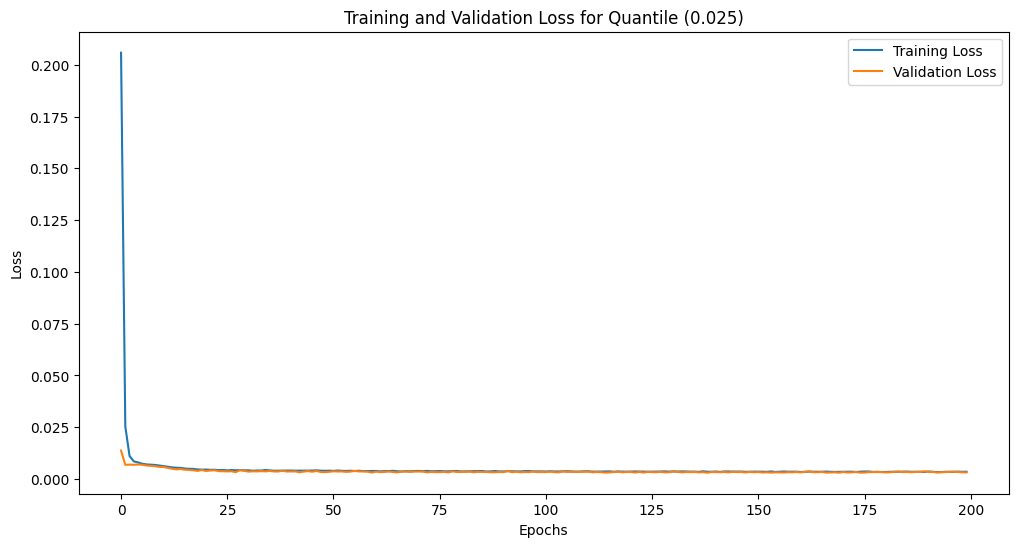

In [120]:
plt.figure(figsize=(12,6))
plt.plot(history_025.history['loss'], label='Training Loss')
plt.plot(history_025.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss for Quantile (0.025)')
plt.show()

In [121]:
t3 = perf_counter()
cqr_amt_025, history_025 = run_ann(X_train, y_train_norm, q=0.025, weight_decay=1e-4, validation_split=0.0)
t4 = perf_counter()

print(f"Elapsed time: {t4 - t3:.2f} seconds")

Epoch 1/200
254/254 [==============================] - 1s 2ms/step - loss: 0.1703 - mae: 0.2393
Epoch 2/200
254/254 [==============================] - 0s 1ms/step - loss: 0.0183 - mae: 0.1770
Epoch 3/200
254/254 [==============================] - 0s 1ms/step - loss: 0.0084 - mae: 0.2038
Epoch 4/200
254/254 [==============================] - 0s 2ms/step - loss: 0.0066 - mae: 0.2102
Epoch 5/200
254/254 [==============================] - 0s 1ms/step - loss: 0.0061 - mae: 0.2026
Epoch 6/200
254/254 [==============================] - 0s 1ms/step - loss: 0.0057 - mae: 0.1981
Epoch 7/200
254/254 [==============================] - 0s 1ms/step - loss: 0.0058 - mae: 0.1986
Epoch 8/200
254/254 [==============================] - 0s 1ms/step - loss: 0.0055 - mae: 0.1980
Epoch 9/200
254/254 [==============================] - 0s 1ms/step - loss: 0.0053 - mae: 0.1867
Epoch 10/200
254/254 [==============================] - 0s 2ms/step - loss: 0.0051 - mae: 0.1801
Epoch 11/200
254/254 [=================

In [122]:

y_pred_amt_lb = cqr_amt_025.predict(X_test).flatten()
y_pred_amt_lb = (y_pred_amt_lb * (y_test.max() - y_test.min()) + y_test.min()).astype('int')
# y_pred_amt_lb = (y_pred_amt_lb * y_test.std() + y_test.mean()).astype('int')

mean_pred_amt = (y_pred_amt_lb + y_pred_amt_ub) / 2

80/80 [==============================] - 0s 879us/step


In [123]:
below_lb = (y_pred_amt_lb >= y_test).sum() / len(y_test)
print('Points Below Lower Bound:', below_lb)

Points Below Lower Bound: 0.013806706114398421


In [124]:
# Predict quantiles on calibration set

calib_ub = cqr_amt_975.predict(X_calib).flatten()
calib_lb = cqr_amt_025.predict(X_calib).flatten()

calib_ub = (calib_ub * (y_calib.max() - y_calib.min()) + y_calib.min()).astype('int')
calib_lb = (calib_lb * (y_calib.max() - y_calib.min()) + y_calib.min()).astype('int')

# Compute conformity scores

alpha = 0.05
E = np.maximum(calib_lb - y_calib, y_calib - calib_ub)

# Compute quantile of conformity scores (with correction)

n_calib = len(y_calib)
q_conformal = np.quantile(E, (1 - alpha) * (1 + 1/n_calib))

print('Conformal quantile:', q_conformal)


64/64 [==============================] - 0s 760us/step
Conformal quantile: -14596.238929980502


In [125]:
# alpha = 0.05

# alpha_lo = alpha / 2
# alpha_hi = 1 - alpha / 2

# E_lo = calib_lb - y_calib  # Lower tail errors
# E_hi = y_calib - calib_ub  # Upper tail errors

# q_lo_conf = np.quantile(E_lo, (1 - alpha_lo) * (1 + 1/n_calib))
# q_hi_conf = np.quantile(E_hi, (1 - alpha_hi) * (1 + 1/n_calib))



Text(0, 0.5, 'Frequency')

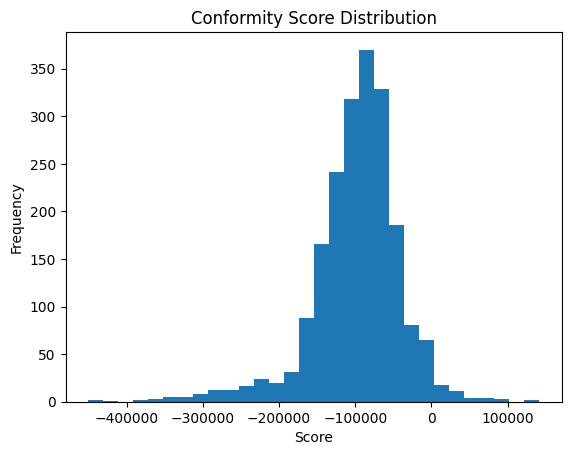

In [126]:

plt.hist(E, bins=30)
plt.title("Conformity Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

In [127]:
print('Median E: ', np.median(E))

calib_lb_corr = calib_lb - np.median(E)
calib_ub_corr = calib_ub + np.median(E)

E_corr = np.maximum(calib_lb_corr - y_calib, y_calib - calib_ub_corr)

q_conformal_corr = np.quantile(E_corr, (1 - alpha) * (1 + 1/n_calib))

print('Conformal quantile (with correction):', q_conformal_corr)

Median E:  -92544.0
Conformal quantile (with correction): 77947.7610700195


In [128]:
# Final CQR intervals

L = y_pred_amt_lb - q_conformal
U = y_pred_amt_ub + q_conformal

# Ensure positive bounds

L = np.maximum(L, 1e-6)
U = np.maximum(U, L + 1e-6)

y_pred_amt_lb = L
y_pred_amt_ub = U


Text(0, 0.5, 'Frequency')

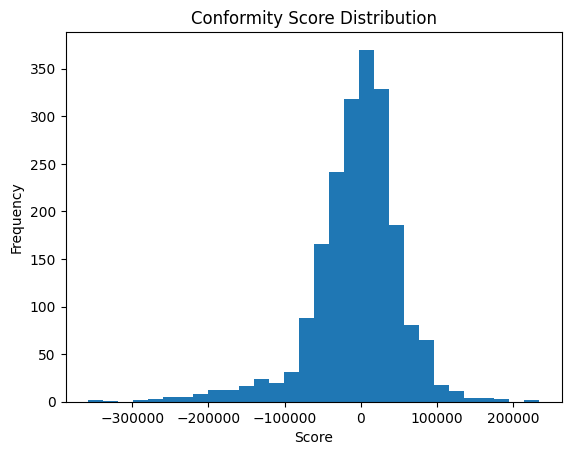

In [129]:

plt.hist(E_corr, bins=30)
plt.title("Conformity Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

In [130]:
L_corr = y_pred_amt_lb - q_conformal_corr
U_corr = y_pred_amt_ub + q_conformal_corr

L_corr = np.maximum(L_corr, 1e-6)
U_corr = np.maximum(U_corr, L_corr + 1e-6)

y_pred_amt_lb_corr = L_corr
y_pred_amt_ub_corr = U_corr

y_pred_amt_lb_corr = y_pred_amt_lb_corr.astype('int')
y_pred_amt_ub_corr = y_pred_amt_ub.astype('int')

In [131]:
def compute_picp(y_lower, y_upper, y_true):
    return np.mean(np.logical_and(y_true >= y_lower, y_true <= y_upper))

def compute_pinrw(y_lower, y_upper, y_true):
    R = np.max(y_true) - np.min(y_true)
    width = np.sqrt(np.mean((y_upper - y_lower) ** 2))
    return width / R

def compute_pinrw(y_lower, y_upper, y_true):
    R = np.max(y_true) - np.min(y_true)
    width = np.sqrt(np.mean((y_upper - y_lower) ** 2))
    return width / R

def cwc_loss_numpy(y_lower, y_upper, y_true, gamma=50, eta=50, mu=0.95):
    picp = compute_picp(y_lower, y_upper, y_true)
    pinrw = compute_pinrw(y_lower, y_upper, y_true)
    penalty = np.exp(eta * (mu - picp))
    cwc = pinrw * (1 + gamma * penalty)
    mpiw = np.mean(y_upper - y_lower)

    return cwc, picp, mpiw, pinrw

In [132]:

cwc, picp, mpiw, pinrw = cwc_loss_numpy(y_pred_amt_lb, y_pred_amt_ub, y_test, gamma=50, eta=50, mu=0.95)
outcome = (y_test >= y_pred_amt_lb) & (y_test <= y_pred_amt_ub)

result = pd.DataFrame({'Original': y_test, 'Predicted': mean_pred_amt,
                        'Lower Bound': y_pred_amt_lb, 'Upper Bound': y_pred_amt_ub,
                        'Outcome': outcome})


result.to_csv(f'Results_CQR_ANN_amt.csv', index=False)


In [133]:
print('PICP: ', picp)
print('PINRW: ', pinrw)
print('CWC: ', cwc)
print('MPIW: ', mpiw)

PICP:  0.9293885601577909
PINRW:  0.24884729360177452
CWC:  35.12067060617025
MPIW:  281575.08111439797


In [135]:
with open('cqr_amt_975.pkl', 'wb') as f:
    pickle.dump(cqr_amt_975, f)

with open('cqr_amt_025.pkl', 'wb') as f:
    pickle.dump(cqr_amt_025, f)

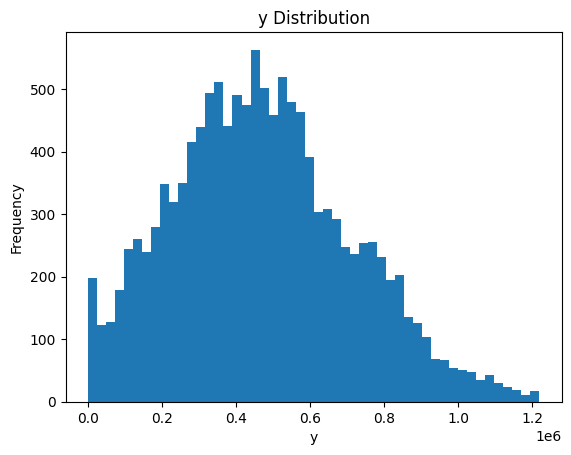

In [137]:
plt.hist(y, bins=50)
plt.title("y Distribution")
plt.xlabel("y")
plt.ylabel("Frequency")
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6c5dcd7e-ee44-459a-9dd6-5c39b2404cb3' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>